# GTEx clustering analysis

In [2]:
library(here)
library(dplyr)
library(Rtsne)
library(ggplot2)
library(scales)
set.seed(123)
library(dplyr)
source(here("config.R"))

here() starts at /home/msubirana/Documents/pivlab/plier2-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
gtex_plier2 <- readRDS(here('output/gtex/gtex_PLIER2.rds'))

In [4]:
gtex_B  <- data.frame(as.matrix(gtex_plier2$B))

In [5]:
head(gtex_B)

,GTEX.1117F.0226.SM.5GZZ7,GTEX.1117F.0426.SM.5EGHI,GTEX.1117F.0526.SM.5EGHJ,GTEX.1117F.0626.SM.5N9CS,GTEX.1117F.0726.SM.5GIEN,GTEX.1117F.1326.SM.5EGHH,GTEX.1117F.2426.SM.5EGGH,GTEX.1117F.2526.SM.5GZY6,GTEX.1117F.2826.SM.5GZXL,GTEX.1117F.2926.SM.5GZYI,⋯,GTEX.ZZPU.1126.SM.5N9CW,GTEX.ZZPU.1226.SM.5N9CK,GTEX.ZZPU.1326.SM.5GZWS,GTEX.ZZPU.1426.SM.5GZZ6,GTEX.ZZPU.1826.SM.5E43L,GTEX.ZZPU.2126.SM.5EGIU,GTEX.ZZPU.2226.SM.5EGIV,GTEX.ZZPU.2426.SM.5E44I,GTEX.ZZPU.2626.SM.5E45Y,GTEX.ZZPU.2726.SM.5NQ8O
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LV1,-0.001996071,-0.17177932,0.37175520,0.29630823,0.0417361423,-0.17759329,0.06224892,-0.133085952,-0.128990027,-0.10360368,⋯,0.12990498,-0.07878671,0.13234024,-0.10201980,-0.04368834,0.233400836,-0.218585487,0.67890371,-0.20314197,0.011847403
LV2,-0.007366913,-0.07904385,-0.06618871,0.02950967,0.0137848493,0.05256078,0.03923502,0.041920420,0.039229944,0.02928616,⋯,-0.03298658,-0.05153172,-0.02177846,-0.04186566,-0.04859947,-0.100795907,-0.005755683,-0.09678039,-0.06160179,-0.024521240
LV3,-0.027424993,-0.12991085,0.26623758,0.08792828,0.3045879024,0.87754667,-0.02713904,0.083964878,0.228213808,-0.13788913,⋯,0.01803576,-0.03783572,0.44882181,0.30492352,-0.01831873,0.003157641,-0.007765243,-0.04482186,-0.11218835,0.167161654
LV4,-0.032972727,-0.01279773,-0.03832356,-0.04645557,-0.0265536246,0.02759365,-0.03862814,-0.072075046,-0.072642116,-0.02687103,⋯,-0.03048997,-0.05856136,-0.03930446,-0.02803328,-0.05697038,-0.139670789,-0.050308190,-0.07187161,-0.01218328,-0.043234313
LV5,-0.237416460,-0.05128643,-0.32621112,-0.17729015,0.0005296356,-0.14077236,-0.13892438,0.109910412,-0.141782781,-0.11271587,⋯,0.23718304,0.14859859,0.08486135,0.04298099,-0.05112148,-0.065985270,0.077490913,-0.21585592,0.28854279,-0.083955540
LV6,0.113137912,-0.02838519,0.09060313,0.03817960,-0.1309868726,-0.08703183,0.08357237,-0.008223451,0.000362112,-0.06311435,⋯,-0.13731111,-0.08775167,0.04220346,-0.11842065,-0.05654503,0.010828251,-0.126906181,-0.02506434,-0.12540800,-0.005404993


In [6]:
colnames(gtex_B) <- gsub("\\.", "-", colnames(gtex_B))

In [7]:
gtex_summary_sig  <- gtex_plier2$summary %>% 
dplyr::filter(FDR < 0.05)  %>% 
dplyr::filter(AUC > 0.7)

head(gtex_summary_sig)
tail(gtex_summary_sig)

,pathway,LV,AUC,p-value,FDR
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,GTEx_Tissues_Artery - Aorta Female 60-69 Up,LV1,0.9813570,1.007707e-14,2.577286e-13
2,GTEx_Tissues_Artery - Aorta Female 20-29 Up,LV1,0.9854310,6.078405e-15,2.014044e-13
3,GTEx_Tissues_Brain - Cerebellar Hemisphere Female 20-29 Up,LV2,0.9869713,5.861843e-13,5.889756e-12
4,GTEx_Tissues_Brain - Cerebellum Female 30-39 Up,LV2,0.9883268,2.850779e-12,2.406058e-11
5,BP_Antigen Receptor-Mediated Signaling Pathway (GO:0050851),LV3,0.8006547,4.646500e-07,2.142976e-06
6,BP_Negative Regulation of T Cell Activation (GO:0050868),LV3,0.7712556,2.552023e-03,8.252519e-03


,pathway,LV,AUC,p-value,FDR
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
299,BP_Male Gamete Generation (GO:0048232),LV201,0.9335841,1.232064e-02,3.311662e-02
300,KEGG_Ribosome,LV202,0.9696335,1.132588e-17,3.186346e-15
301,BP_Aerobic Electron Transport Chain (GO:0019646),LV202,0.8638916,2.634417e-06,1.152045e-05
302,BP_Cellular Respiration (GO:0045333),LV202,0.7168919,8.627369e-04,3.020105e-03
303,BP_Proton Motive Force-Driven Mitochondrial ATP Synthesis (GO:0042776),LV202,0.8136849,6.741986e-04,2.380852e-03
304,BP_Response to Fibroblast Growth Factor (GO:0071774),LV203,0.8964596,4.953230e-03,1.487732e-02


In [8]:
gtex_meta <- read.table(
    here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt'), 
    sep = '\t', 
    header = TRUE,
    quote = "", 
    fill = TRUE,
    comment.char = "" 
)

In [9]:
head(gtex_meta)

,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,⋯,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<dbl>
1,GTEX-1117F-0003-SM-58Q7G,NA,B1,,NA,Blood,Whole Blood,0013756,1188,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,GTEX-1117F-0003-SM-5DWSB,NA,B1,,NA,Blood,Whole Blood,0013756,1188,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,GTEX-1117F-0003-SM-6WBT7,NA,B1,,NA,Blood,Whole Blood,0013756,1188,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,GTEX-1117F-0011-R10a-SM-AHZ7F,NA,"B1, A1",,NA,Brain,Brain - Frontal Cortex (BA9),0009834,1193,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,GTEX-1117F-0011-R10b-SM-CYKQ8,NA,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,GTEX-1117F-0226-SM-5GZZ7,0,B1,"2 pieces, ~15% vessel stroma, rep delineated",6.8,Adipose Tissue,Adipose - Subcutaneous,0002190,1214,1125,⋯,14648800,11999300,0.00315785,14669500,50.0354,0.00310538,0.99474,NA,0,50.1944


In [10]:
table(colnames(gtex_B) %in% gtex_meta$SAMPID)


 TRUE 
17382 

In [11]:
tissues_to_keep <- names(table(gtex_meta$SMTS)[table(gtex_meta$SMTS) >= 200])

gtex_meta_filtered <- gtex_meta %>% dplyr::filter(SMTS %in% tissues_to_keep)

table(gtex_meta_filtered$SMTS)


Adipose Tissue  Adrenal Gland          Blood   Blood Vessel    Bone Marrow 
          1327            275           3480           1473            217 
         Brain         Breast          Colon      Esophagus          Heart 
          3326            480            821           1582           1141 
         Liver           Lung         Muscle          Nerve       Pancreas 
           251            867           1132            722            360 
     Pituitary       Prostate           Skin         Spleen        Stomach 
           301            262           2014            260            381 
        Testis        Thyroid 
           406            812 

In [12]:
gtex_B <- gtex_B %>%
    dplyr::select(any_of(gtex_meta_filtered$SAMPID))

# T-SNE of GTEx samples

In [13]:
mat_jitter <- jitter(t(gtex_B), factor = 1e-6)
tsne_res <- Rtsne(mat_jitter, perplexity = 30, max_iter = 1000, verbose = TRUE, check_duplicates = FALSE)
tsne_df <- data.frame(
  sample_id = rownames(mat_jitter),
  tSNE_1    = tsne_res$Y[,1],
  tSNE_2    = tsne_res$Y[,2]
) %>%
  left_join(
    gtex_meta_filtered %>% select(SAMPID, SMTS) %>% rename(sample_id = SAMPID, tissue = SMTS),
    by = "sample_id"
  )
tsne_centroids <- tsne_df %>%
  group_by(tissue) %>%
  summarise(tSNE_1 = mean(tSNE_1), tSNE_2 = mean(tSNE_2))

Performing PCA
Read the 16417 x 50 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 30.000000, and theta = 0.500000
Computing input similarities...
Building tree...
 - point 10000 of 16417
Done in 4.81 seconds (sparsity = 0.007597)!
Learning embedding...
Iteration 50: error is 102.988009 (50 iterations in 2.04 seconds)
Iteration 100: error is 89.192582 (50 iterations in 2.19 seconds)
Iteration 150: error is 77.773689 (50 iterations in 2.08 seconds)
Iteration 200: error is 74.301051 (50 iterations in 2.05 seconds)
Iteration 250: error is 72.537626 (50 iterations in 2.04 seconds)
Iteration 300: error is 2.948442 (50 iterations in 1.92 seconds)
Iteration 350: error is 2.631980 (50 iterations in 1.86 seconds)
Iteration 400: error is 2.399362 (50 iterations in 1.85 seconds)
Iteration 450: error is 2.231382 (50 iterations in 1.85 seconds)
Iteration 500: error is 2.103350 (50 iterations in 1.83 seconds)
Iteration 550: error is 2.003763 (50 iterations in 

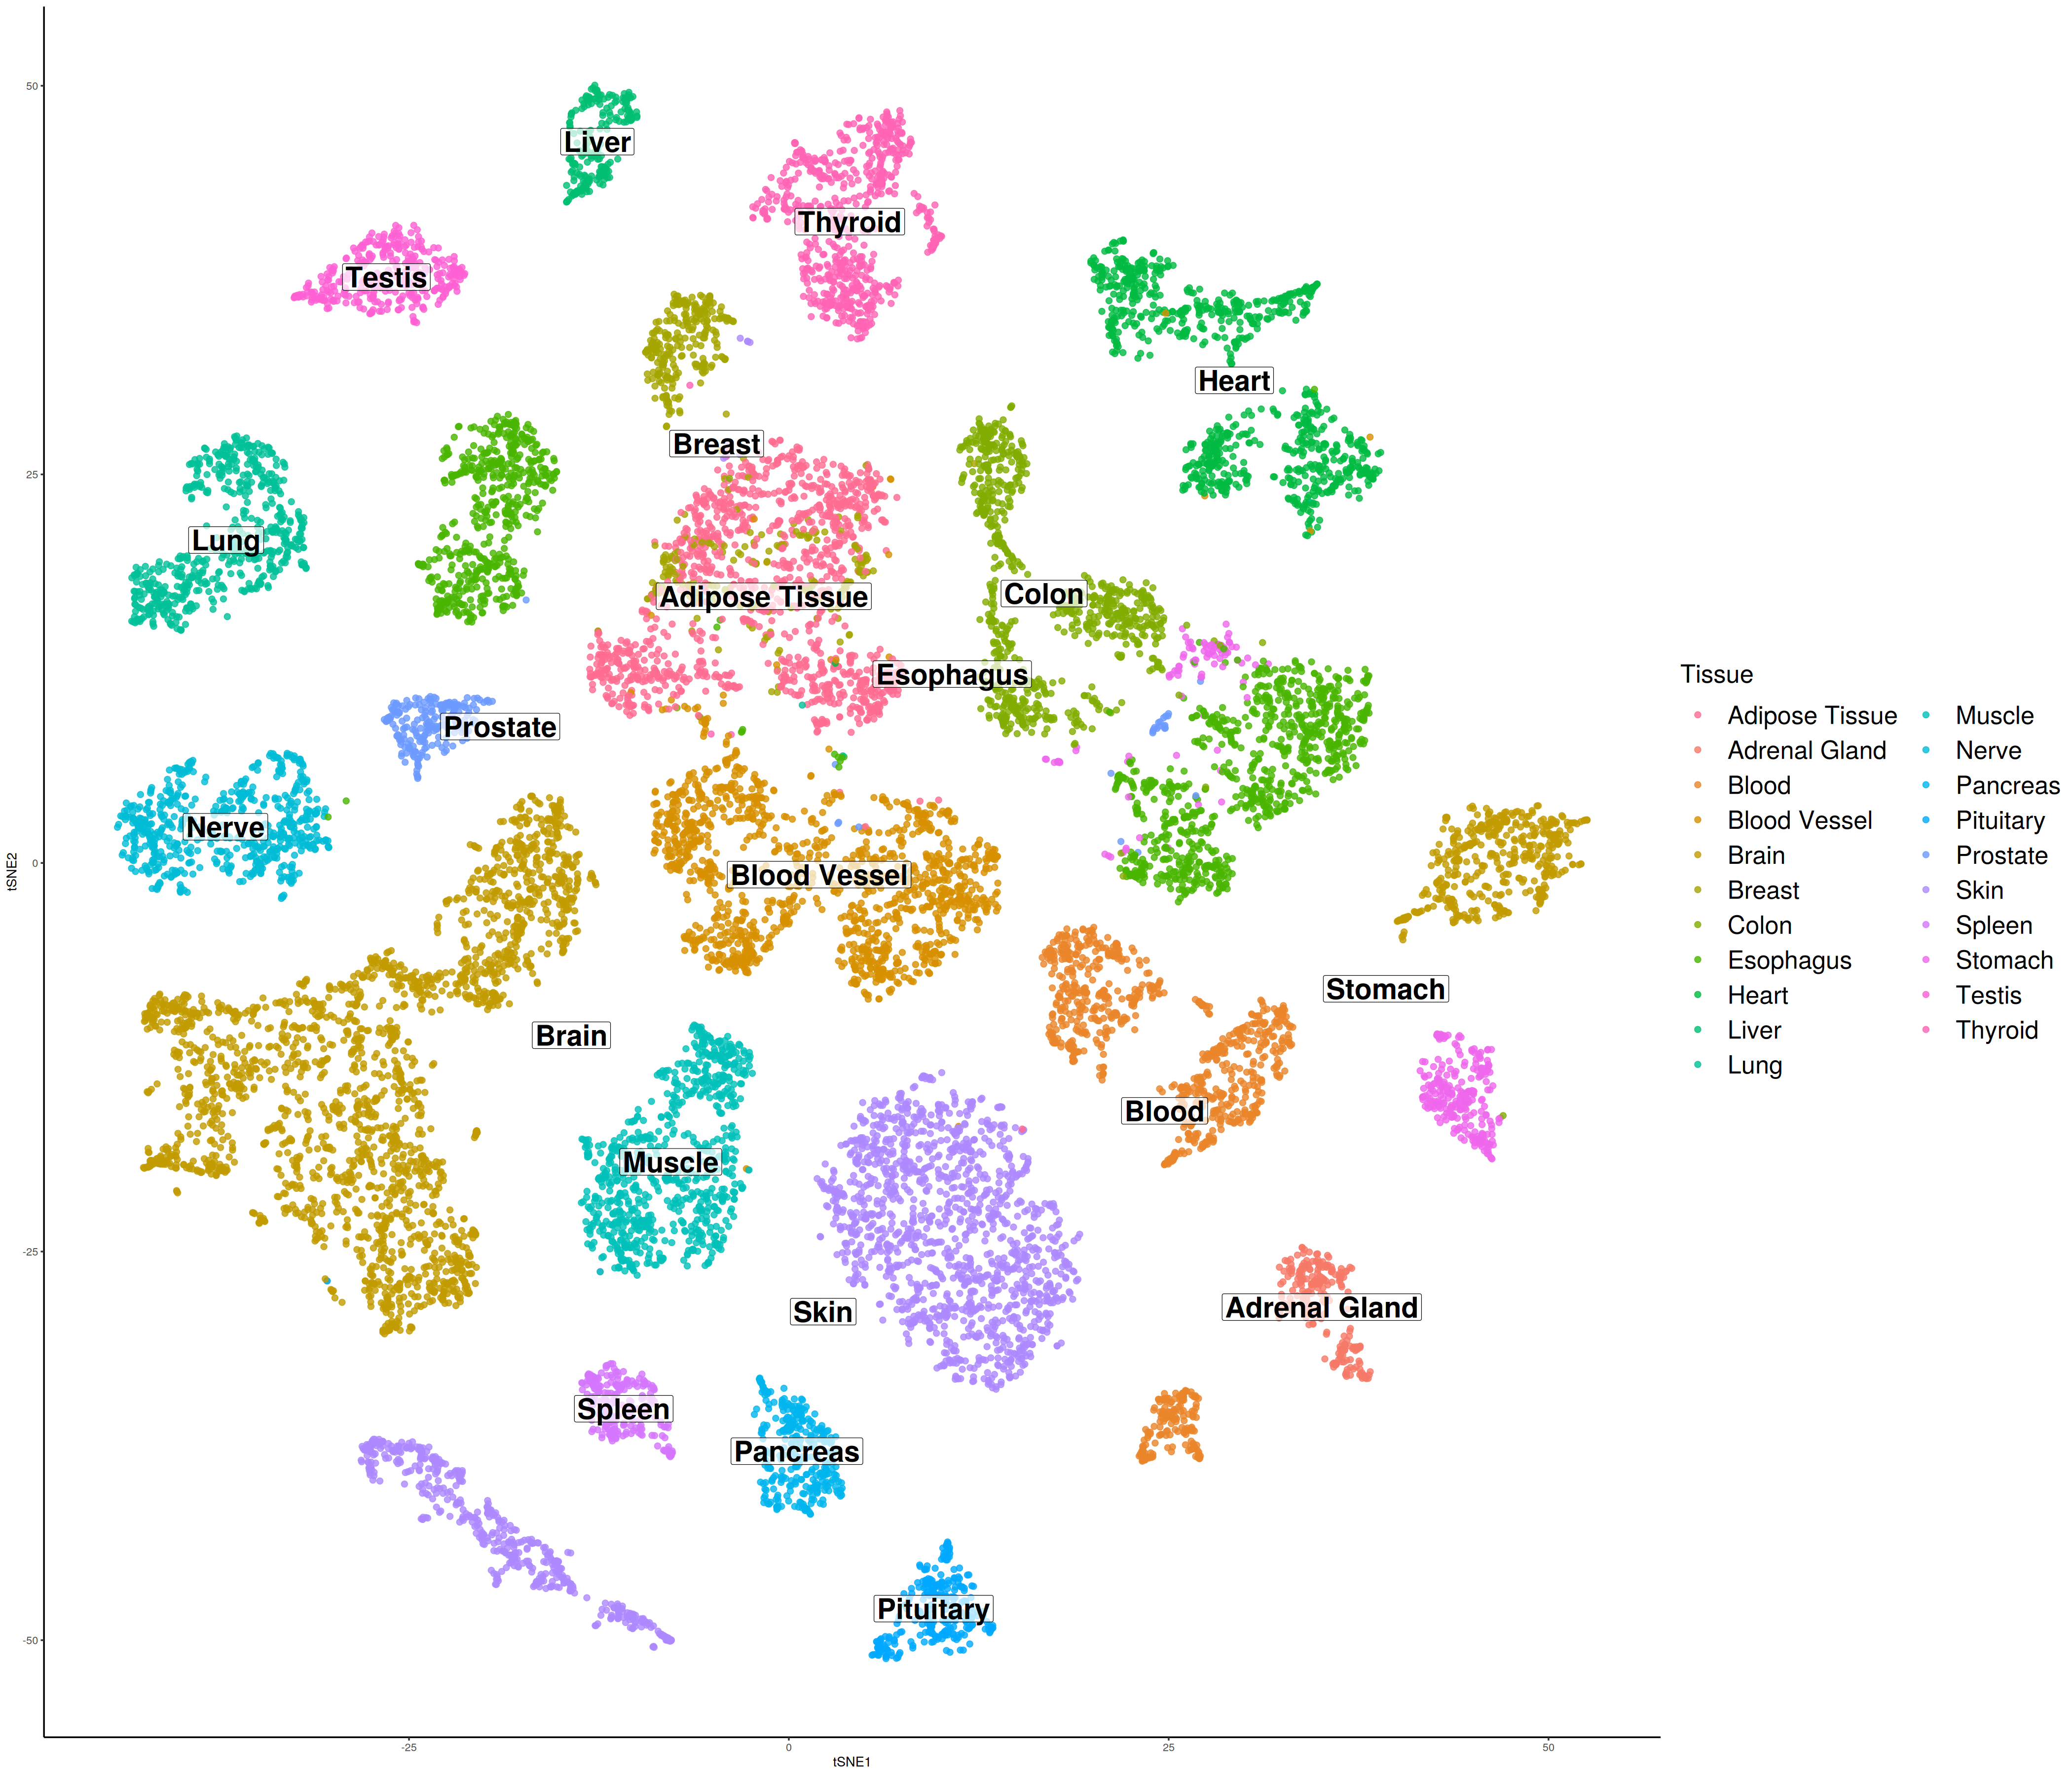

In [ ]:
options(repr.plot.width = 35, repr.plot.height = 30)

n_tissues <- n_distinct(tsne_df$tissue)
palette_hue <- hue_pal(h = c(0, 360), c = 100, l = 65)(n_tissues)

ggplot(tsne_df, aes(tSNE_1, tSNE_2, colour = tissue)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_label(
    data = tsne_centroids,
    aes(label = tissue),
    size = 12, fontface = "bold",
    colour = "black", fill = "white", alpha = 0.7
  ) +
  scale_color_manual(values = palette_hue) +
  labs(
    x = "tSNE1", y = "tSNE2", colour = "Tissue"
  ) +
  theme_classic(base_size = 16) +
  theme(
    legend.key.size = unit(1.5, "cm"),
    legend.text       = element_text(size = 30),
    legend.title      = element_text(size = 30)
  )

# Most important LVs for tissue

In [13]:
gtex_meta %>%
dplyr::select(SMTSD)  %>% 
table()

SMTSD
                   Adipose - Subcutaneous 
                                      763 
             Adipose - Visceral (Omentum) 
                                      564 
                            Adrenal Gland 
                                      275 
                           Artery - Aorta 
                                      450 
                        Artery - Coronary 
                                      253 
                          Artery - Tibial 
                                      770 
                                  Bladder 
                                       21 
                         Brain - Amygdala 
                                      177 
 Brain - Anterior cingulate cortex (BA24) 
                                      213 
          Brain - Caudate (basal ganglia) 
                                      291 
            Brain - Cerebellar Hemisphere 
                                      263 
                       Brain - Cerebellum 
     

In [14]:
meta <- gtex_meta %>%
  select(SAMPID, SMTSD) %>%
  mutate(SAMPID = trimws(SAMPID)) %>% 
  slice(match(colnames(gtex_B), SAMPID))

tissues <- unique(meta$SMTSD)

best_LV_by_tissue <- sapply(tissues, function(tiss) {
  group <- meta$SMTSD == tiss
  # compute Mann-Whitney U statistic for each LV
  mann_whitney_stats <- apply(gtex_B, 1, function(vals) {
    x1 <- vals[group]; x2 <- vals[!group]
    wilcox.test(x1, x2, exact = FALSE)$statistic
  })
  names(which.max(mann_whitney_stats))
})

best_LV_by_tissue  <- data.frame(best_LV_by_tissue)
colnames(best_LV_by_tissue) <- 'LV'
best_LV_by_tissue <-  best_LV_by_tissue  %>% 
tibble::rownames_to_column('tissue')

In [15]:
best_LV_by_tissue

tissue,LV
<chr>,<chr>
Adipose - Subcutaneous,LV130
Muscle - Skeletal,LV39
Artery - Tibial,LV166
Artery - Coronary,LV179
Heart - Atrial Appendage,LV52
Adipose - Visceral (Omentum),LV151
Breast - Mammary Tissue,LV35
Skin - Not Sun Exposed (Suprapubic),LV169
Brain - Cortex,LV121


In [16]:
output_data_dir <- config$GTEx$DATASET_FOLDER
summ_all_summaries <- readRDS(file.path(output_data_dir, "all_summaries.rds"))

In [17]:
dplyr::left_join(best_LV_by_tissue, summ_all_summaries)

Joining with `by = join_by(LV)`


tissue,LV,pathway_prior
<chr>,<chr>,<chr>
Adipose - Subcutaneous,LV130,"all_GTEx_Tissues_Breast - Mammary Tissue Female 70-79 Up, GTEx_Tissues_V8_2023_Adipose - Subcutaneous Male 60-69 Up, GTEx_Tissues_V8_2023_Adipose - Visceral (Omentum) Female 20-29 Up, GTEx_Tissues_V8_2023_Adipose - Subcutaneous Female 20-29 Up, GTEx_Tissues_V8_2023_Breast - Mammary Tissue Male 30-39 Up, GTEx_Tissues_V8_2023_Adipose - Subcutaneous Female 30-39 Up, GTEx_Tissues_V8_2023_Adipose - Subcutaneous Female 40-49 Up, GTEx_Tissues_V8_2023_Adipose - Subcutaneous Female 70-79 Up, Human_Gene_Atlas_Adipocyte, KEGG_2021_Human_Fatty acid elongation"
Muscle - Skeletal,LV39,"GO_Biological_Process_2025_Positive Regulation of Microtubule Polymerization (GO:0031116), GO_Biological_Process_2025_Regulation of Interferon-Beta Production (GO:0032648), GTEx_Tissues_V8_2023_Muscle - Skeletal Male 60-69 Up, GTEx_Tissues_V8_2023_Muscle - Skeletal Female 20-29 Up, GTEx_Tissues_V8_2023_Muscle - Skeletal Male 30-39 Up, GTEx_Tissues_V8_2023_Muscle - Skeletal Male 20-29 Up, GTEx_Tissues_V8_2023_Muscle - Skeletal Female 30-39 Up, GTEx_Tissues_V8_2023_Muscle - Skeletal Female 70-79 Up, GWAS_Catalog_2025_Creatine Kinase Levels, Human_Gene_Atlas_SkeletalMuscle, KEGG_2021_Human_Proteasome, KEGG_2021_Human_Thyroid hormone signaling pathway, Metabolomics_Workbench_Metabolites_2022_S-Adenosylhomocysteine, Proteomics_Drug_Atlas_2023_H-Arg(NO2)-OH Up, TF_Perturbations_Followed_by_Expression_PPARA OE MOUSE GSE5777 CREEDSID GENE 271 DOWN"
Artery - Tibial,LV166,"GTEx_Tissues_V8_2023_Artery - Tibial Female 20-29 Up, GTEx_Tissues_V8_2023_Artery - Tibial Female 50-59 Up, GTEx_Tissues_V8_2023_Artery - Tibial Female 30-39 Up, GTEx_Tissues_V8_2023_Artery - Coronary Female 40-49 Up, GTEx_Tissues_V8_2023_Artery - Tibial Male 70-79 Up, GTEx_Tissues_V8_2023_Artery - Tibial Female 70-79 Up, GWAS_Catalog_2025_Migraine Wo Aura, Human_Gene_Atlas_Thalamus, UK_Biobank_GWAS_v1_Palmar fascial fibromatosis M13 DUPUTRYEN"
Artery - Coronary,LV179,"GTEx_Tissues_V8_2023_Heart - Atrial Appendage Male 50-59 Up, GTEx_Tissues_V8_2023_Artery - Coronary Male 50-59 Up, GTEx_Tissues_V8_2023_Artery - Tibial Female 20-29 Up, GTEx_Tissues_V8_2023_Artery - Aorta Female 30-39 Up, GTEx_Tissues_V8_2023_Artery - Coronary Male 30-39 Up, GTEx_Tissues_V8_2023_Artery - Coronary Female 40-49 Up, GTEx_Tissues_V8_2023_Artery - Coronary Female 30-39 Up"
Heart - Atrial Appendage,LV52,"all_GTEx_Tissues_Heart - Atrial Appendage Female 30-39 Up, all_GTEx_Tissues_Heart - Atrial Appendage Male 20-29 Up, all_GTEx_Tissues_Heart - Left Ventricle Female 30-39 Up, all_GTEx_Tissues_Heart - Atrial Appendage Male 70-79 Up, GO_Biological_Process_2025_Heart Contraction (GO:0060047), GTEx_Tissues_V8_2023_Heart - Atrial Appendage Male 60-69 Up, GTEx_Tissues_V8_2023_Heart - Left Ventricle Female 50-59 Up, GTEx_Tissues_V8_2023_Heart - Atrial Appendage Male 40-49 Up, GTEx_Tissues_V8_2023_Heart - Atrial Appendage Female 30-39 Up, GTEx_Tissues_V8_2023_Heart - Atrial Appendage Male 20-29 Up, GTEx_Tissues_V8_2023_Heart - Atrial Appendage Male 70-79 Up, GTEx_Tissues_V8_2023_Heart - Atrial Appendage Female 70-79 Up, KEGG_2021_Human_Cardiac muscle contraction, UK_Biobank_GWAS_v1_Other professional qualifications 6138 6"
Adipose - Visceral (Omentum),LV151,"all_GTEx_Tissues_Adipose - Visceral (Omentum) Male 50-59 Up, GTEx_Tissues_V8_2023_Breast - Mammary Tissue Female 60-69 Up, GTEx_Tissues_V8_2023_Breast - Mammary Tissue Male 50-59 Up, GTEx_Tissues_V8_2023_Adipose - Subcutaneous Female 30-39 Up, GTEx_Tissues_V8_2023_Adipose - Subcutaneous Male 20-29 Up, GTEx_Tissues_V8_2023_Adipose - Visceral (Omentum) Male 70-79 Up, GTEx_Tissues_V8_2023_Breast - Mammary Tissue Male 70-79 Up"
Breast - Mammary Tissue,LV35,"Chromosome_Location_chr12q12, GTEx_Tissues_V8_2023_Kidney - Cortex Female 50-59 Up, GTEx_Tissues_V8_2023_Kidney - Cortex Male 50-59 Up, GTEx_Tissues_V8_2023_Fallopian Tube Female 50-59 Up, Human_Gene_Atlas_AdrenalCortex"
Skin - Not Sun Exposed (Suprapubic),LV16

## Traits

In [18]:
traits_gtex <- readRDS(here('data/gtex/phenoplier/gtex-phenoplier.rds'))
head(traits_gtex)

,phenotype,phenotype_desc,lv,pvalue,fdr
,<fct>,<fct>,<fct>,<dbl>,<dbl>
0,1498,Coffee intake,LV163,2.484123e-06,0.003965477
1,1498,Coffee intake,LV73,3.482571e-05,0.032528463
2,1498,Coffee intake,LV158,8.523213e-05,0.061765081
3,1498,Coffee intake,LV135,5.915558e-03,0.573669473
4,1498,Coffee intake,LV110,6.121001e-03,0.579520527
5,1498,Coffee intake,LV137,6.815828e-03,0.594918544


In [26]:
traits_gtex_sig <- traits_gtex %>%
dplyr::select(lv, phenotype_desc, fdr) %>%
dplyr::rename(LV=lv, FDR=fdr, phenotype=phenotype_desc) %>% 
dplyr::filter(FDR < 0.1) %>% 
dplyr::select(LV, phenotype) %>%
group_by(LV) %>%
summarise(phenotype = paste(phenotype, collapse = '; '))

head(traits_gtex_sig)
dim(traits_gtex_sig)
nrow(gtex_B)

LV,phenotype
<fct>,<chr>
LV1,"Treatment/medication code: amiodarone (20003_1140888502); Job SOC coding: Merchandisers and window dressers; Job SOC coding: Travel agency managers; Job coding: travel agency manager/owner, tourist manager (22601_12263368); Job coding: merchandiser, window dresser (22601_71253330)"
LV10,"Other disorders of patella; Non-cancer illness code, self-reported: headaches (not migraine); Relative age of first facial hair; Other and unsepcified mononeuropathies, also in other diseases"
LV100,"Treatment/medication code: asacol 400mg e/c tablet (20003_1140865580); Treatment/medication code: indometacin (20003_1140909936); Treatment/medication code: tacrolimus (20003_1140911642); Diagnoses - main ICD10: R29 Other symptoms and signs involving the nervous and musculoskeletal systems; Non-cancer illness code, self-reported: helicobacter pylori; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Insulin; Non-cancer illness code, self-reported: type 1 diabetes; Type 1 diabetes; Age diabetes diagnosed; Started insulin within one year diagnosis of diabetes; Diagnoses - main ICD10: E10 Insulin-dependent diabetes mellitus; Type 1 diabetes with ketoacidosis; Diabetic ketoacidosis"
LV101,"Job SOC coding: Engineering professionals n.e.c.; Treatment/medication code: allopurinol (20003_1140875408); Non-cancer illness code, self-reported: gout; Ever had laser treatment for glaucoma or high eye pressure: Both eyes"
LV102,Neutrophill percentage; White blood cell (leukocyte) count; Eosinophill percentage; Crohn's disease of large intestine; Lymphocyte percentage; Neutrophill count; Diagnoses - main ICD10: K52 Other non-infective gastro-enteritis and colitis; Eosinophill count
LV103,"Doctor diagnosed hayfever or allergic rhinitis; Eosinophill percentage; Physical violence by partner or ex-partner as an adult; Blood clot, DVT, bronchitis, emphysema, asthma, rhinitis, eczema, allergy diagnosed by doctor: None of the above; Eosinophill count"


[1] 184   2

[1] 206

In [27]:
head(traits_gtex_sig)

LV,phenotype
<fct>,<chr>
LV1,"Treatment/medication code: amiodarone (20003_1140888502); Job SOC coding: Merchandisers and window dressers; Job SOC coding: Travel agency managers; Job coding: travel agency manager/owner, tourist manager (22601_12263368); Job coding: merchandiser, window dresser (22601_71253330)"
LV10,"Other disorders of patella; Non-cancer illness code, self-reported: headaches (not migraine); Relative age of first facial hair; Other and unsepcified mononeuropathies, also in other diseases"
LV100,"Treatment/medication code: asacol 400mg e/c tablet (20003_1140865580); Treatment/medication code: indometacin (20003_1140909936); Treatment/medication code: tacrolimus (20003_1140911642); Diagnoses - main ICD10: R29 Other symptoms and signs involving the nervous and musculoskeletal systems; Non-cancer illness code, self-reported: helicobacter pylori; Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Insulin; Non-cancer illness code, self-reported: type 1 diabetes; Type 1 diabetes; Age diabetes diagnosed; Started insulin within one year diagnosis of diabetes; Diagnoses - main ICD10: E10 Insulin-dependent diabetes mellitus; Type 1 diabetes with ketoacidosis; Diabetic ketoacidosis"
LV101,"Job SOC coding: Engineering professionals n.e.c.; Treatment/medication code: allopurinol (20003_1140875408); Non-cancer illness code, self-reported: gout; Ever had laser treatment for glaucoma or high eye pressure: Both eyes"
LV102,Neutrophill percentage; White blood cell (leukocyte) count; Eosinophill percentage; Crohn's disease of large intestine; Lymphocyte percentage; Neutrophill count; Diagnoses - main ICD10: K52 Other non-infective gastro-enteritis and colitis; Eosinophill count
LV103,"Doctor diagnosed hayfever or allergic rhinitis; Eosinophill percentage; Physical violence by partner or ex-partner as an adult; Blood clot, DVT, bronchitis, emphysema, asthma, rhinitis, eczema, allergy diagnosed by doctor: None of the above; Eosinophill count"


In [28]:
dplyr::left_join(best_LV_by_tissue, traits_gtex_sig)

Joining with `by = join_by(LV)`


tissue,LV,phenotype
<chr>,<chr>,<chr>
Adipose - Subcutaneous,LV130,NA
Muscle - Skeletal,LV39,"Trunk fat percentage; FI6 : conditional arithmetic; Arm fat percentage (right); Bread type: White; Reason for glasses/contact lenses: For short-sightedness, i.e. only or mainly for distance viewing such as driving, cinema etc (called 'myopia'); Other appendicitis; Arm fat percentage (left); Age when periods started (menarche)"
Artery - Tibial,LV166,Job coding: building site foreman or supervisor (22601_81492535)
Artery - Coronary,LV179,"Treatment/medication code: spasmonal 60mg capsule (20003_1140865336); Treatment/medication code: peppermint oil product (20003_1140865414); Diagnoses - main ICD10: O62 Abnormalities of forces of labour; Diagnoses - main ICD10: I25 Chronic ischaemic heart disease; Ischaemic heart disease, wide definition"
Heart - Atrial Appendage,LV52,"Diagnoses - main ICD10: N81 Female genital prolapse; Type milk consumed: other type of milk; Pulse rate; Pulse rate, automated reading"
Adipose - Visceral (Omentum),LV151,Ever had laser treatment for glaucoma or high eye pressure: No; Treatment/medication code: reductil 10mg capsule (20003_1141174508); Ever had laser treatment for glaucoma or high eye pressure: Both eyes
Breast - Mammary Tissue,LV35,"3mm cylindrical power angle (left); Diagnoses - main ICD10: K70 Alcoholic liver disease; 3mm weak meridian angle (left); Illnesses of mother: High blood pressure; Intracranial trauma; Job SOC coding: Artists; Lesion of plantar nerve; Trigger finger; severe traumatic brain injury, does not include concussion; Diagnoses - main ICD10: M65 Synovitis and tenosynovitis; Diagnoses - main ICD10: S06 Intracranial injury"
Skin - Not Sun Exposed (Suprapubic),LV169,Feelings of worthlessness during worst period of depression; Fractured bone site(s): Wrist; Fractured/broken bones in last 5 years; Heel broadband ultrasound attenuation (left); Job code - deduced: Housing and welfare officers; Heel broadband ultrasound attenuation (right); Treatment/medication code: salmeterol product (20003_1141157264)
Brain - Cortex,LV121,Risk taking; Time to complete round; Waist circumference; Number of incorrect matches in round
